In [1]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

data_folder = "./Data/HS300_data"
csv_files = glob.glob(os.path.join(data_folder, '*.csv'))
df_list = []
for file in csv_files:
    temp_df = pd.read_csv(file)
    df_list.append(temp_df)

data = pd.concat(df_list, ignore_index=True)
print(f"数据读取完毕，总行数: {len(data)}")
# data.to_csv("./Data/HS300_data/data.csv", index=False)

数据读取完毕，总行数: 1465200


### 实测最佳因子

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

data = pd.read_csv("./Data/HS300_data/data.csv")
fund_cols = ['market_cap', 'basic_eps', 'pe_ratio']
price_cols = ['close', 'open', 'turnover_ratio', 'volume', 'net_amount_s', 'net_amount_m', 'net_pct_l', 'net_pct_xl']
use_cols = ['time', 'code'] + price_cols + fund_cols
df = data[use_cols].copy()

df = df.dropna(subset=['time', 'code'])
df['time'] = pd.to_datetime(df['time'], errors='coerce')
num_cols = price_cols + fund_cols
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')
df = df.sort_values(['code', 'time']).reset_index(drop=True)
df['ret'] = df.groupby('code')['close'].pct_change()
df[fund_cols] = df.groupby('code')[fund_cols].ffill()
df.head()

,time,code,close,open,turnover_ratio,volume,net_amount_s,net_amount_m,net_pct_l,net_pct_xl,market_cap,basic_eps,pe_ratio,ret
0,2016-01-04,000001.XSHE,7.64,8.09,0.4774,83611173.0,10869.30,3025.23,-2.41,-18.63,1621.1730,0.43,7.4202,NaN
1,2016-01-05,000001.XSHE,7.68,7.60,0.5619,98415241.0,2749.33,2801.57,-1.05,-6.30,1631.1891,0.43,7.4661,0.005236
2,2016-01-06,000001.XSHE,7.77,7.70,0.4369,76519934.0,353.93,-701.26,-1.40,1.99,1649.7904,0.43,7.5512,0.011719
3,2016-01-07,000001.XSHE,7.37,7.69,0.1481,25930853.0,3263.86,3527.46,4.30,-39.15,1565.3691,0.43,7.1648,-0.051480
4,2016-01-08,000001.XSHE,7.49,7.55,0.6333,110917294.0,5648.19,4095.04,-4.22,-7.50,1591.1248,0.43,7.2827,0.016282


In [2]:
df = df.sort_values(['code', 'time']).copy()

all_factors = ["alpha"]

df['abs_overnight_ret'] = (df['open'] / df.groupby('code')['close'].shift(1) - 1).abs()
df['prev_turnover'] = df.groupby('code')['turnover_ratio'].shift(1)
df['alpha'] = -df.groupby('code').apply(
    lambda x: x['abs_overnight_ret'].rolling(20).corr(x['prev_turnover'])
).reset_index(level=0, drop=True)

# 截面 MAD 去极值
def mad_filter(series):
    md = series.median()
    mad = (series - md).abs().median()
    mad_e = 1.483 * mad
    upper = md + 3 * mad_e
    lower = md - 3 * mad_e
    return series.clip(lower=lower, upper=upper)
for f in all_factors:
    df[f] = df.groupby('time', group_keys=False)[f].apply(mad_filter)

display(df.head())

,time,code,close,open,turnover_ratio,volume,net_amount_s,net_amount_m,net_pct_l,net_pct_xl,market_cap,basic_eps,pe_ratio,ret,abs_overnight_ret,prev_turnover,alpha
0,2016-01-04,000001.XSHE,7.64,8.09,0.4774,83611173.0,10869.30,3025.23,-2.41,-18.63,1621.1730,0.43,7.4202,NaN,NaN,NaN,NaN
1,2016-01-05,000001.XSHE,7.68,7.60,0.5619,98415241.0,2749.33,2801.57,-1.05,-6.30,1631.1891,0.43,7.4661,0.005236,0.005236,0.4774,NaN
2,2016-01-06,000001.XSHE,7.77,7.70,0.4369,76519934.0,353.93,-701.26,-1.40,1.99,1649.7904,0.43,7.5512,0.011719,0.002604,0.5619,NaN
3,2016-01-07,000001.XSHE,7.37,7.69,0.1481,25930853.0,3263.86,3527.46,4.30,-39.15,1565.3691,0.43,7.1648,-0.051480,0.010296,0.4369,NaN
4,2016-01-08,000001.XSHE,7.49,7.55,0.6333,110917294.0,5648.19,4095.04,-4.22,-7.50,1591.1248,0.43,7.2827,0.016282,0.024423,0.1481,NaN


In [3]:
# 划分数据集
df['time'] = pd.to_datetime(df['time'], errors='coerce')
df = df.dropna(subset=['time']).sort_values(['code', 'time'])

train_df = df[(df['time'] >= '2016-01-01') & (df['time'] <= '2020-12-31')].copy()
val_df   = df[(df['time'] >= '2021-01-01') & (df['time'] <= '2022-12-31')].copy()
test_df  = df[df['time'] >= '2023-01-01'].copy()

# 采样为周频
def resample_to_weekly(df, factor_cols):
    cols = ['time', 'code', 'open', 'close'] + factor_cols
    df = df[cols].copy()
    df['time'] = pd.to_datetime(df['time'], errors='coerce')
    df = df.dropna(subset=['time'])
    df = df.sort_values(['code', 'time'])
    agg_dict = {
        'open': 'first',
        'close': 'last',
        **{f: 'last' for f in factor_cols}
    }
    res = (
        df.groupby(['code', pd.Grouper(key='time', freq='W-Fri')], observed=True)
          .agg(agg_dict)
          .dropna(subset=['close'])
          .reset_index()
    )
    res['close'] = pd.to_numeric(res['close'], errors='coerce')
    res['next_ret'] = res.groupby('code', observed=True)['close'].shift(-1) / res['close'] - 1
    return res.dropna(subset=['next_ret']).reset_index(drop=True)

train_weekly = resample_to_weekly(train_df, all_factors)
val_weekly = resample_to_weekly(val_df, all_factors)
test_weekly = resample_to_weekly(test_df, all_factors)

display(train_weekly.head())

,code,time,open,close,alpha,next_ret
0,000001.XSHE,2016-01-08,8.09,7.49,NaN,-0.058745
1,000001.XSHE,2016-01-15,7.41,7.05,NaN,-0.005674
2,000001.XSHE,2016-01-22,6.97,7.01,NaN,-0.038516
3,000001.XSHE,2016-01-29,7.01,6.74,NaN,-0.007418
4,000001.XSHE,2016-02-05,6.73,6.69,-0.318973,0.011958


训练集

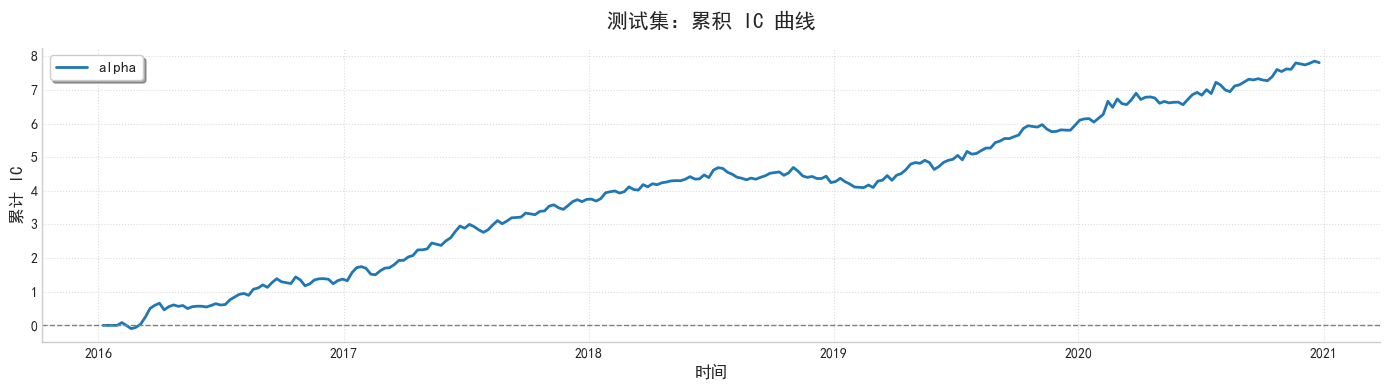

In [4]:
def calc_ic_series(weekly_df, factor_cols, method='spearman', min_obs=30):
    ic_dict = {}
    for f in factor_cols:
        def calc_one_date(x):
            tmp = x[[f, 'next_ret']].dropna()
            if len(tmp) < min_obs:
                return np.nan
            return tmp[f].corr(tmp['next_ret'], method=method)

        ic_s = weekly_df.groupby('time').apply(calc_one_date)
        ic_dict[f] = ic_s
    ic_df = pd.DataFrame(ic_dict).sort_index()
    ic_df.index.name = 'time'
    return ic_df

ic_df = calc_ic_series(train_weekly, all_factors, method='spearman', min_obs=20)
cum_ic_df = ic_df.cumsum()

plt.figure(figsize=(14, 4))
ax = plt.gca()
cmap = plt.get_cmap('tab10')

cum_ic_plot = cum_ic_df.ffill().fillna(0)
for i, f in enumerate(all_factors):
    plt.plot(cum_ic_plot.index, cum_ic_plot[f], label=f, color=cmap(i), linewidth=2)

plt.axhline(0, linestyle='--', color='gray', linewidth=1)
plt.title('测试集：累积 IC 曲线', fontsize=15, pad=15)
plt.xlabel('时间', fontsize=12)
plt.ylabel('累计 IC', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.legend(loc='best', fontsize=11, frameon=True, fancybox=True, shadow=True)
plt.tight_layout()
plt.savefig('./Pictures/Hw4_cumulative_ic.png', dpi=300)
plt.show()

验证集

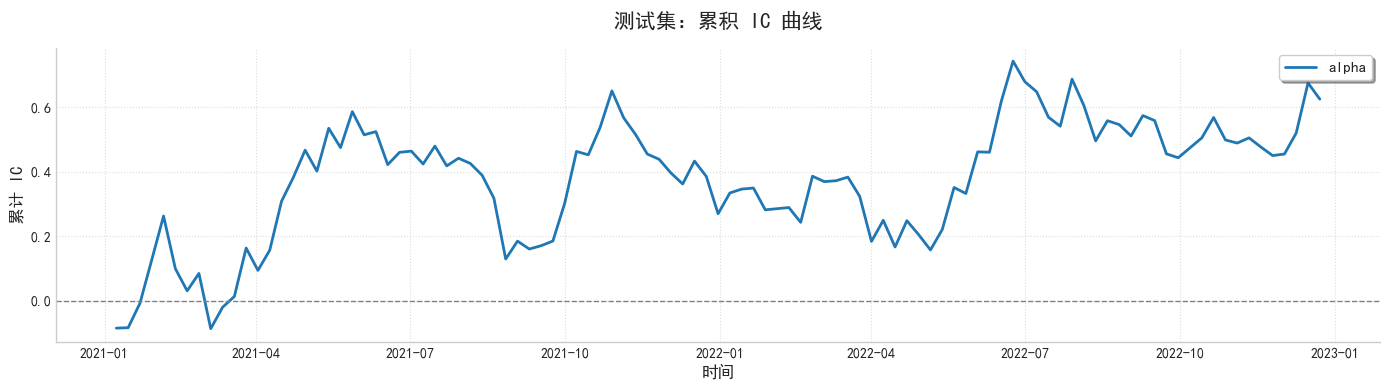

,IC_mean,IC_positive_ratio
alpha,0.006192,0.49505


In [5]:
# IC
val_ic_df = calc_ic_series(val_weekly, all_factors, method='spearman', min_obs=20)
val_cum_ic_df = val_ic_df.cumsum()

plt.figure(figsize=(14, 4))
ax = plt.gca()
cmap = plt.get_cmap('tab10')

val_cum_ic_plot = val_cum_ic_df.ffill().fillna(0)
for i, f in enumerate(all_factors):
    plt.plot(val_cum_ic_plot.index, val_cum_ic_plot[f], label=f, color=cmap(i), linewidth=2)

plt.axhline(0, linestyle='--', color='gray', linewidth=1)
plt.title('测试集：累积 IC 曲线', fontsize=15, pad=15)
plt.xlabel('时间', fontsize=12)
plt.ylabel('累计 IC', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.legend(loc='best', fontsize=11, frameon=True, fancybox=True, shadow=True)
plt.tight_layout()
plt.savefig('./Pictures/Hw4_cumulative_ic_val.png', dpi=300)
plt.show()

summary = pd.DataFrame({
    'IC_mean': val_ic_df.mean(),
    'IC_positive_ratio': (val_ic_df > 0).mean()
}).sort_values('IC_mean', ascending=False)
display(summary)

测试集

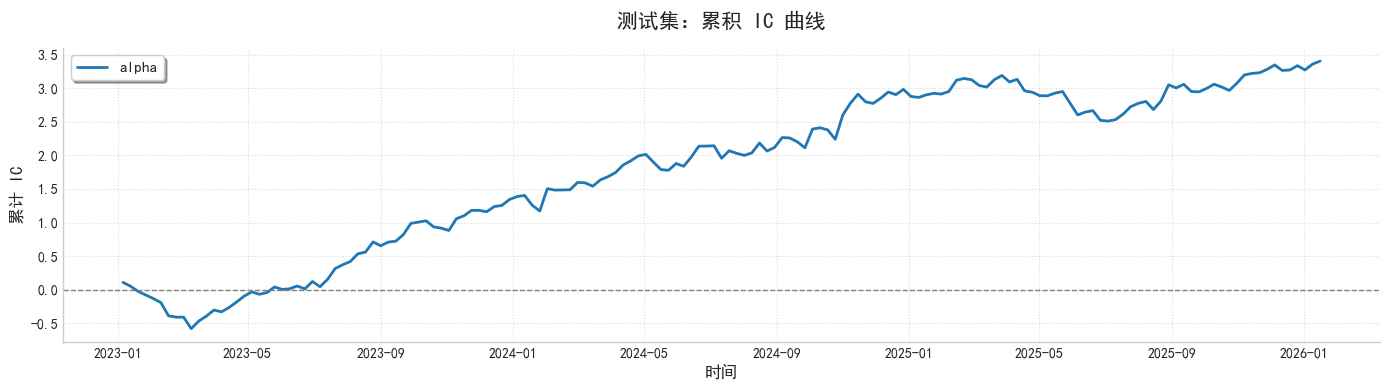

,IC_mean,IC_positive_ratio
alpha,0.021824,0.596154


In [6]:
# IC
test_ic_df = calc_ic_series(test_weekly, all_factors, method='spearman', min_obs=20)
test_cum_ic_df = test_ic_df.cumsum()

plt.figure(figsize=(14, 4))
ax = plt.gca()
cmap = plt.get_cmap('tab10')

test_cum_ic_plot = test_cum_ic_df.ffill().fillna(0)
for i, f in enumerate(all_factors):
    plt.plot(test_cum_ic_plot.index, test_cum_ic_plot[f], label=f, color=cmap(i), linewidth=2)

plt.axhline(0, linestyle='--', color='gray', linewidth=1)
plt.title('测试集：累积 IC 曲线', fontsize=15, pad=15)
plt.xlabel('时间', fontsize=12)
plt.ylabel('累计 IC', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.legend(loc='best', fontsize=11, frameon=True, fancybox=True, shadow=True)
plt.tight_layout()
plt.savefig('./Pictures/Hw4_cumulative_ic_test.png', dpi=300)
plt.show()

summary = pd.DataFrame({
    'IC_mean': test_ic_df.mean(),
    'IC_positive_ratio': (test_ic_df > 0).mean()
}).sort_values('IC_mean', ascending=False)
display(summary)

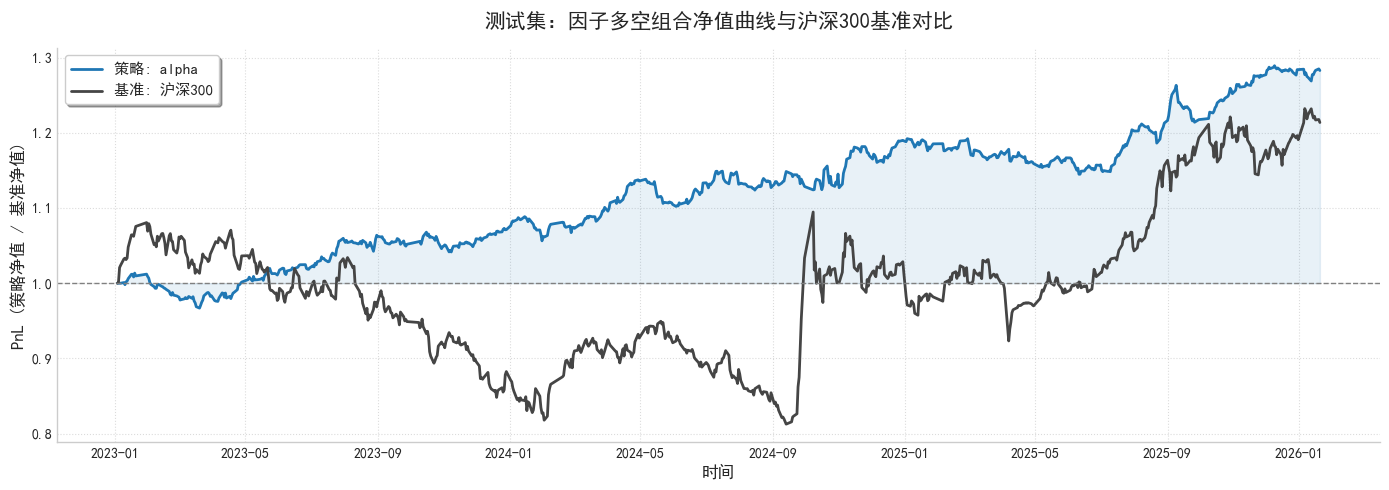

因子多空组合与基准回测指标表现对比


,平均收益率(日频),日收益率标准差,年化收益率,夏普比率,最大回撤
因子/基准,,,,,
alpha,0.000344,0.003721,0.090551,1.068741,-0.045927
沪深300基准,0.000319,0.010704,0.083747,0.331488,-0.248039


In [8]:
daily_ret = test_df.pivot(index='time', columns='code', values='ret').fillna(0)

# 基准：沪深300指数
hs300 = pd.read_excel("./Data/HS300_data/沪深300指数.xlsx")
hs300 = hs300[['日期', '沪深300指数']].copy()
hs300.columns = ['time', 'close']
hs300.dropna(inplace=True)
hs300['time'] = pd.to_datetime(hs300['time'])
hs300.set_index('time', inplace=True)
hs300.sort_index(inplace=True)
hs300['ret'] = hs300['close'].pct_change().fillna(0)

plt.figure(figsize=(14, 5))
ax = plt.gca()
metrics_list = []

cmap = plt.get_cmap('tab10')

for i, f in enumerate(all_factors):
    factor_pivot = test_weekly.pivot(index='time', columns='code', values=f)
    def get_position_weights(row):
        s = row.dropna()
        if len(s) < 12: return pd.Series(0.0, index=row.index)
        r = s.rank(ascending=False, method='first')
        try:
            groups = pd.qcut(r, q=12, labels=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])
            w = pd.Series(0.0, index=row.index)
            long_cond = (groups == 1)
            short_cond = (groups == 12)
            # 多空等权配置 0.5
            if long_cond.sum() > 0: w[s.index[long_cond]] = 0.5 / long_cond.sum()
            if short_cond.sum() > 0: w[s.index[short_cond]] = -0.5 / short_cond.sum()
            return w
        except:
            return pd.Series(0.0, index=row.index)
    weekly_w = factor_pivot.apply(get_position_weights, axis=1)
    daily_w = weekly_w.reindex(daily_ret.index).ffill().shift(1).fillna(0)
    strat_daily_ret = (daily_w * daily_ret).sum(axis=1)
    
    net_value = (1 + strat_daily_ret).cumprod()
    plt.plot(net_value.index, net_value, label=f'策略: {f}', color=cmap(i), linewidth=2)
    plt.fill_between(net_value.index, 1, net_value, color=cmap(i), alpha=0.1)
    
    daily_mean = strat_daily_ret.mean()
    daily_std = strat_daily_ret.std(ddof=1)
    
    ann_ret = (1 + daily_mean) ** 252 - 1
    ann_std = daily_std * np.sqrt(252)
    # 先前作业算过的rf_ann=0.02742
    sharpe = (ann_ret - 0.02742) / ann_std if ann_std != 0 else np.nan
    roll_max = net_value.cummax()
    drawdown = net_value / roll_max - 1
    max_dd = drawdown.min()
    
    metrics_list.append({
        '因子/基准': f,
        '平均收益率(日频)': daily_mean,
        '日收益率标准差': daily_std,
        '年化收益率': ann_ret,
        '夏普比率': sharpe,
        '最大回撤': max_dd
    })

# 基准
hs300_test = hs300.reindex(daily_ret.index).fillna(0)
bench_daily_ret = hs300_test['ret']
bench_net_value = (1 + bench_daily_ret).cumprod()

plt.plot(bench_net_value.index, bench_net_value, label='基准: 沪深300', color='#454545', linewidth=2)

bench_mean = bench_daily_ret.mean()
bench_std = bench_daily_ret.std(ddof=1)
bench_ann_ret = (1 + bench_mean) ** 252 - 1
bench_ann_std = bench_std * np.sqrt(252)

bench_sharpe = (bench_ann_ret - 0.02742) / bench_ann_std if bench_ann_std != 0 else np.nan
bench_roll_max = bench_net_value.cummax()
bench_dd = bench_net_value / bench_roll_max - 1
bench_max_dd = bench_dd.min()

metrics_list.append({
    '因子/基准': '沪深300基准',
    '平均收益率(日频)': bench_mean,
    '日收益率标准差': bench_std,
    '年化收益率': bench_ann_ret,
    '夏普比率': bench_sharpe,
    '最大回撤': bench_max_dd
})

plt.axhline(1, linestyle='--', color='gray', linewidth=1)
plt.title('测试集：因子多空组合净值曲线与沪深300基准对比', fontsize=15, pad=15)
plt.xlabel('时间', fontsize=12)
plt.ylabel('PnL (策略净值 / 基准净值)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.legend(loc='upper left', fontsize=11, frameon=True, fancybox=True, shadow=True)
plt.tight_layout()
plt.savefig('./Pictures/Hw4_strategy_pnl_with_benchmark.png', dpi=300)
plt.show()

metrics_df = pd.DataFrame(metrics_list).set_index('因子/基准')
print("因子多空组合与基准回测指标表现对比")
display(metrics_df.round(6))

### 其他因子

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

data = pd.read_csv("./Data/HS300_data/data.csv")
fund_cols = ['market_cap', 'basic_eps', 'pe_ratio']
price_cols = ['close', 'open', 'turnover_ratio']
use_cols = ['time', 'code'] + price_cols + fund_cols
df = data[use_cols].copy()

df = df.dropna(subset=['time', 'code'])
df['time'] = pd.to_datetime(df['time'], errors='coerce')
num_cols = price_cols + fund_cols
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')
df = df.sort_values(['code', 'time']).reset_index(drop=True)
df['ret'] = df.groupby('code')['close'].pct_change()
df[fund_cols] = df.groupby('code')[fund_cols].ffill()
df.head()

,time,code,close,open,turnover_ratio,market_cap,basic_eps,pe_ratio,ret
0,2016-01-04,000001.XSHE,7.64,8.09,0.4774,1621.1730,0.43,7.4202,NaN
1,2016-01-05,000001.XSHE,7.68,7.60,0.5619,1631.1891,0.43,7.4661,0.005236
2,2016-01-06,000001.XSHE,7.77,7.70,0.4369,1649.7904,0.43,7.5512,0.011719
3,2016-01-07,000001.XSHE,7.37,7.69,0.1481,1565.3691,0.43,7.1648,-0.051480
4,2016-01-08,000001.XSHE,7.49,7.55,0.6333,1591.1248,0.43,7.2827,0.016282


In [10]:
df = df.sort_values(['code', 'time']).copy()

fund_factors = ['alpha_fund_1', 'alpha_fund_2', 'alpha_fund_3']
tech_factors = ['alpha_pv_1', 'alpha_pv_2', 'alpha_pv_3']
all_factors = fund_factors + tech_factors

# 1个技术因子
df['alpha_pv_1'] = -df.groupby('code')['turnover_ratio'].transform(lambda x: x.rolling(20).mean())

df['alpha_pv_2'] = -df.groupby('code')['turnover_ratio'].transform(lambda x: x.rolling(5, min_periods=5).std())

df['alpha_pv_3'] = -df.groupby('code')['ret'].transform(lambda x: x.rolling(5, min_periods=5).mean())

# 3个基本面因子
df['alpha_fund_1'] = -df.groupby('code')['market_cap'].transform(lambda x: x.pct_change(20))

ep_pe = 1 / df['pe_ratio'].replace(0, np.nan)
df['alpha_fund_2'] = ep_pe.groupby(df['time']).rank(pct=True)

ep = df['basic_eps'] / df['close'].replace(0, np.nan)
df['alpha_fund_3'] = ep.groupby(df['time']).rank(pct=True)

# 截面 MAD 去极值
def mad_filter(series):
    md = series.median()
    mad = (series - md).abs().median()
    mad_e = 1.483 * mad
    upper = md + 3 * mad_e
    lower = md - 3 * mad_e
    return series.clip(lower=lower, upper=upper)
for f in all_factors:
    df[f] = df.groupby('time', group_keys=False)[f].apply(mad_filter)

display(df.head())

,time,code,close,open,turnover_ratio,market_cap,basic_eps,pe_ratio,ret,alpha_pv_1,alpha_pv_2,alpha_pv_3,alpha_fund_1,alpha_fund_2,alpha_fund_3
0,2016-01-04,000001.XSHE,7.64,8.09,0.4774,1621.1730,0.43,7.4202,NaN,NaN,NaN,NaN,NaN,0.956522,0.96633
1,2016-01-05,000001.XSHE,7.68,7.60,0.5619,1631.1891,0.43,7.4661,0.005236,NaN,NaN,NaN,NaN,0.953177,0.96633
2,2016-01-06,000001.XSHE,7.77,7.70,0.4369,1649.7904,0.43,7.5512,0.011719,NaN,NaN,NaN,NaN,0.959866,0.96633
3,2016-01-07,000001.XSHE,7.37,7.69,0.1481,1565.3691,0.43,7.1648,-0.051480,NaN,NaN,NaN,NaN,0.959866,0.96633
4,2016-01-08,000001.XSHE,7.49,7.55,0.6333,1591.1248,0.43,7.2827,0.016282,NaN,-0.185859,NaN,NaN,0.956522,0.96633


In [11]:
# 划分数据集
df['time'] = pd.to_datetime(df['time'], errors='coerce')
df = df.dropna(subset=['time']).sort_values(['code', 'time'])

train_df = df[(df['time'] >= '2016-01-01') & (df['time'] <= '2020-12-31')].copy()
val_df   = df[(df['time'] >= '2021-01-01') & (df['time'] <= '2022-12-31')].copy()
test_df  = df[df['time'] >= '2023-01-01'].copy()

In [12]:
# 采样为周频
def resample_to_weekly(df, factor_cols):
    cols = ['time', 'code', 'open', 'close'] + factor_cols
    df = df[cols].copy()
    df['time'] = pd.to_datetime(df['time'], errors='coerce')
    df = df.dropna(subset=['time'])
    df = df.sort_values(['code', 'time'])
    agg_dict = {
        'open': 'first',
        'close': 'last',
        **{f: 'last' for f in factor_cols}
    }
    res = (
        df.groupby(['code', pd.Grouper(key='time', freq='W-Fri')], observed=True)
          .agg(agg_dict)
          .dropna(subset=['close'])
          .reset_index()
    )
    res['close'] = pd.to_numeric(res['close'], errors='coerce')
    res['next_ret'] = res.groupby('code', observed=True)['close'].shift(-1) / res['close'] - 1
    return res.dropna(subset=['next_ret']).reset_index(drop=True)

train_weekly = resample_to_weekly(train_df, all_factors)
val_weekly = resample_to_weekly(val_df, all_factors)
test_weekly = resample_to_weekly(test_df, all_factors)

display(train_weekly.head())

,code,time,open,close,alpha_fund_1,alpha_fund_2,alpha_fund_3,alpha_pv_1,alpha_pv_2,alpha_pv_3,next_ret
0,000001.XSHE,2016-01-08,8.09,7.49,NaN,0.956522,0.966330,NaN,-0.185859,NaN,-0.058745
1,000001.XSHE,2016-01-15,7.41,7.05,NaN,0.953177,0.946128,NaN,-0.121090,0.011903,-0.005674
2,000001.XSHE,2016-01-22,6.97,7.01,NaN,0.956522,0.952862,NaN,-0.070147,0.000984,-0.038516
3,000001.XSHE,2016-01-29,7.01,6.74,NaN,0.959866,0.942761,-0.444925,-0.121424,0.007470,-0.007418
4,000001.XSHE,2016-02-05,6.73,6.69,0.107914,0.963211,0.942761,-0.404285,-0.055293,0.001395,0.011958


训练集

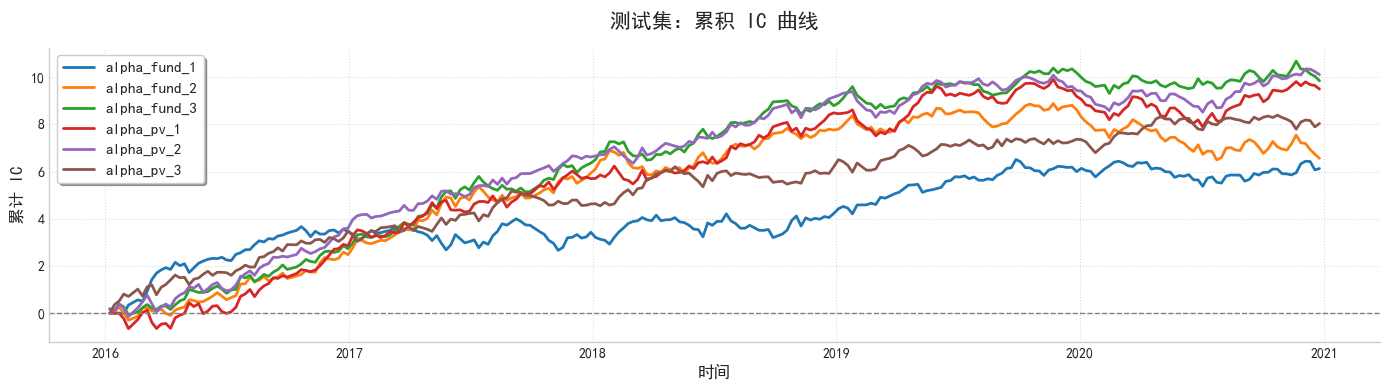

In [13]:
def calc_ic_series(weekly_df, factor_cols, method='spearman', min_obs=30):
    ic_dict = {}
    for f in factor_cols:
        def calc_one_date(x):
            tmp = x[[f, 'next_ret']].dropna()
            if len(tmp) < min_obs:
                return np.nan
            return tmp[f].corr(tmp['next_ret'], method=method)

        ic_s = weekly_df.groupby('time').apply(calc_one_date)
        ic_dict[f] = ic_s
    ic_df = pd.DataFrame(ic_dict).sort_index()
    ic_df.index.name = 'time'
    return ic_df

ic_df = calc_ic_series(train_weekly, all_factors, method='spearman', min_obs=20)
cum_ic_df = ic_df.cumsum()

plt.figure(figsize=(14, 4))
ax = plt.gca()
cmap = plt.get_cmap('tab10')

cum_ic_plot = cum_ic_df.ffill().fillna(0)
for i, f in enumerate(all_factors):
    plt.plot(cum_ic_plot.index, cum_ic_plot[f], label=f, color=cmap(i), linewidth=2)

plt.axhline(0, linestyle='--', color='gray', linewidth=1)
plt.title('测试集：累积 IC 曲线', fontsize=15, pad=15)
plt.xlabel('时间', fontsize=12)
plt.ylabel('累计 IC', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.legend(loc='best', fontsize=11, frameon=True, fancybox=True, shadow=True)
plt.tight_layout()
plt.savefig('./Pictures/Hw4_cumulative_ic_others.png', dpi=300)
plt.show()

验证集

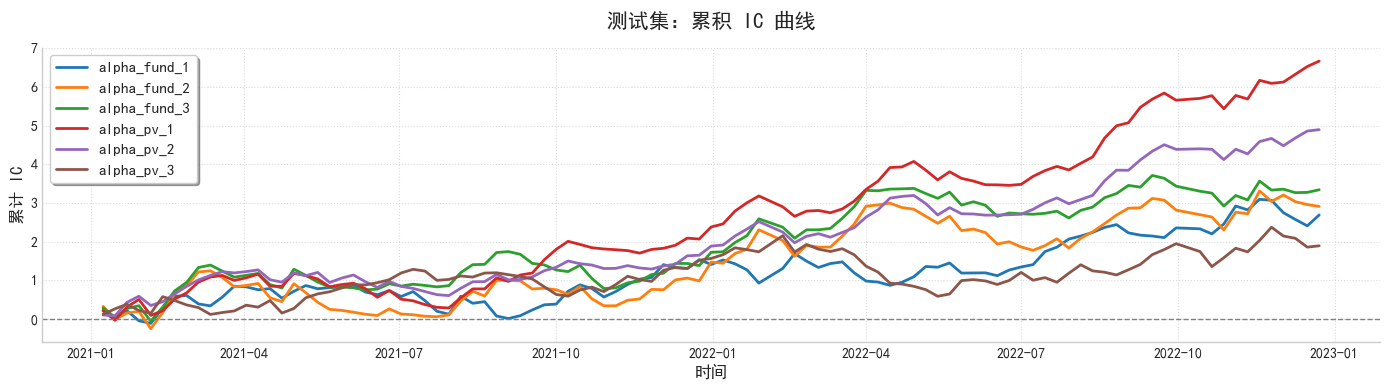

In [14]:
# IC
val_ic_df = calc_ic_series(val_weekly, all_factors, method='spearman', min_obs=20)
val_cum_ic_df = val_ic_df.cumsum()

plt.figure(figsize=(14, 4))
ax = plt.gca()
cmap = plt.get_cmap('tab10')

val_cum_ic_plot = val_cum_ic_df.ffill().fillna(0)
for i, f in enumerate(all_factors):
    plt.plot(val_cum_ic_plot.index, val_cum_ic_plot[f], label=f, color=cmap(i), linewidth=2)

plt.axhline(0, linestyle='--', color='gray', linewidth=1)
plt.title('测试集：累积 IC 曲线', fontsize=15, pad=15)
plt.xlabel('时间', fontsize=12)
plt.ylabel('累计 IC', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.legend(loc='best', fontsize=11, frameon=True, fancybox=True, shadow=True)
plt.tight_layout()
plt.savefig('./Pictures/Hw4_cumulative_ic_val_others.png', dpi=300)
plt.show()

测试集

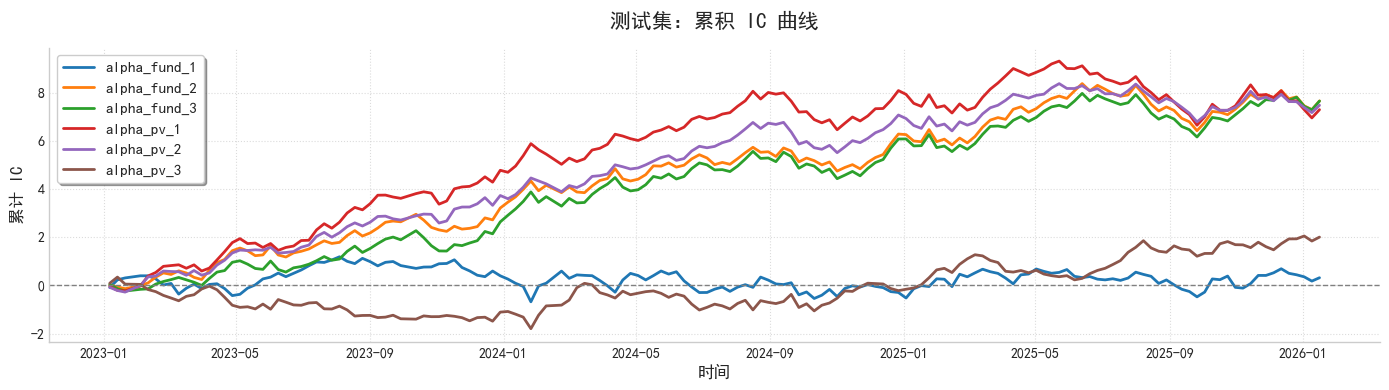

In [15]:
# IC
test_ic_df = calc_ic_series(test_weekly, all_factors, method='spearman', min_obs=20)
test_cum_ic_df = test_ic_df.cumsum()

plt.figure(figsize=(14, 4))
ax = plt.gca()
cmap = plt.get_cmap('tab10')

test_cum_ic_plot = test_cum_ic_df.ffill().fillna(0)
for i, f in enumerate(all_factors):
    plt.plot(test_cum_ic_plot.index, test_cum_ic_plot[f], label=f, color=cmap(i), linewidth=2)

plt.axhline(0, linestyle='--', color='gray', linewidth=1)
plt.title('测试集：累积 IC 曲线', fontsize=15, pad=15)
plt.xlabel('时间', fontsize=12)
plt.ylabel('累计 IC', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.legend(loc='best', fontsize=11, frameon=True, fancybox=True, shadow=True)
plt.tight_layout()
plt.savefig('./Pictures/Hw4_cumulative_ic_test_others.png', dpi=300)
plt.show()

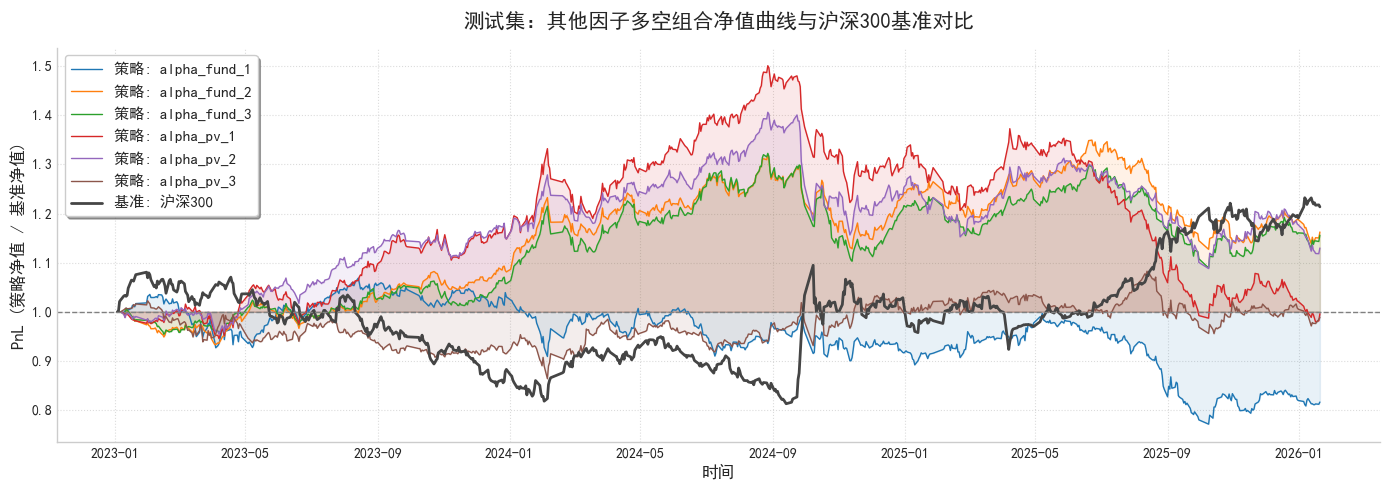

因子多空组合与基准回测指标表现对比


,平均收益率(日频),日收益率标准差,年化收益率,夏普比率,最大回撤
因子/基准,,,,,
alpha_fund_1,-0.000235,0.008976,-0.057473,-0.595773,-0.278487
alpha_fund_2,0.000232,0.007532,0.060222,0.274336,-0.164848
alpha_fund_3,0.000225,0.007619,0.058368,0.255878,-0.176484
alpha_pv_1,0.000040,0.009519,0.010073,-0.114806,-0.347648
alpha_pv_2,0.000202,0.008621,0.052340,0.182095,-0.226360
alpha_pv_3,0.000018,0.008191,0.004458,-0.176601,-0.155361
沪深300基准,0.000319,0.010704,0.083747,0.331488,-0.248039


In [16]:
daily_ret = test_df.pivot(index='time', columns='code', values='ret').fillna(0)

# 基准：沪深300指数
hs300 = pd.read_excel("./Data/HS300_data/沪深300指数.xlsx")
hs300 = hs300[['日期', '沪深300指数']].copy()
hs300.columns = ['time', 'close']
hs300.dropna(inplace=True)
hs300['time'] = pd.to_datetime(hs300['time'])
hs300.set_index('time', inplace=True)
hs300.sort_index(inplace=True)
hs300['ret'] = hs300['close'].pct_change().fillna(0)

plt.figure(figsize=(14, 5))
ax = plt.gca()
metrics_list = []

cmap = plt.get_cmap('tab10')

for i, f in enumerate(all_factors):
    factor_pivot = test_weekly.pivot(index='time', columns='code', values=f)
    # 根据alpha构造weight
    def get_position_weights(row):
        s = row.dropna()
        if len(s) < 12: return pd.Series(0.0, index=row.index)
        r = s.rank(ascending=False, method='first')
        try:
            groups = pd.qcut(r, q=12, labels=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])
            w = pd.Series(0.0, index=row.index)
            long_cond = (groups == 1)
            short_cond = (groups == 12)
            # 多空等权配置 0.5
            if long_cond.sum() > 0: w[s.index[long_cond]] = 0.5 / long_cond.sum()
            if short_cond.sum() > 0: w[s.index[short_cond]] = -0.5 / short_cond.sum()
            return w
        except:
            return pd.Series(0.0, index=row.index)
    weekly_w = factor_pivot.apply(get_position_weights, axis=1)
    daily_w = weekly_w.reindex(daily_ret.index).ffill().shift(1).fillna(0)
    strat_daily_ret = (daily_w * daily_ret).sum(axis=1)
    
    net_value = (1 + strat_daily_ret).cumprod()
    if f == 'alpha_pv_1':
        save_net_value = net_value.copy()
    plt.plot(net_value.index, net_value, label=f'策略: {f}', color=cmap(i), linewidth=1)
    plt.fill_between(net_value.index, 1, net_value, color=cmap(i), alpha=0.1)
    
    daily_mean = strat_daily_ret.mean()
    daily_std = strat_daily_ret.std(ddof=1)
    
    ann_ret = (1 + daily_mean) ** 252 - 1
    ann_std = daily_std * np.sqrt(252)
    # 先前作业算过的rf_ann=0.02742
    sharpe = (ann_ret - 0.02742) / ann_std if ann_std != 0 else np.nan
    roll_max = net_value.cummax()
    drawdown = net_value / roll_max - 1
    max_dd = drawdown.min()
    
    metrics_list.append({
        '因子/基准': f,
        '平均收益率(日频)': daily_mean,
        '日收益率标准差': daily_std,
        '年化收益率': ann_ret,
        '夏普比率': sharpe,
        '最大回撤': max_dd
    })

# 基准
hs300_test = hs300.reindex(daily_ret.index).fillna(0)
bench_daily_ret = hs300_test['ret']
bench_net_value = (1 + bench_daily_ret).cumprod()

plt.plot(bench_net_value.index, bench_net_value, label='基准: 沪深300', color='#454545', linewidth=2)

bench_mean = bench_daily_ret.mean()
bench_std = bench_daily_ret.std(ddof=1)
bench_ann_ret = (1 + bench_mean) ** 252 - 1
bench_ann_std = bench_std * np.sqrt(252)
bench_sharpe = (bench_ann_ret - 0.02742) / bench_ann_std if bench_ann_std != 0 else np.nan
bench_roll_max = bench_net_value.cummax()
bench_dd = bench_net_value / bench_roll_max - 1
bench_max_dd = bench_dd.min()

metrics_list.append({
    '因子/基准': '沪深300基准',
    '平均收益率(日频)': bench_mean,
    '日收益率标准差': bench_std,
    '年化收益率': bench_ann_ret,
    '夏普比率': bench_sharpe,
    '最大回撤': bench_max_dd
})

plt.axhline(1, linestyle='--', color='gray', linewidth=1)
plt.title('测试集：其他因子多空组合净值曲线与沪深300基准对比', fontsize=15, pad=15)
plt.xlabel('时间', fontsize=12)
plt.ylabel('PnL (策略净值 / 基准净值)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.legend(loc='upper left', fontsize=11, frameon=True, fancybox=True, shadow=True)
plt.tight_layout()
plt.savefig('./Pictures/Hw4_strategy_pnl_with_benchmark_others.png', dpi=300)
plt.show()

metrics_df = pd.DataFrame(metrics_list).set_index('因子/基准')
print("因子多空组合与基准回测指标表现对比")
display(metrics_df.round(6))

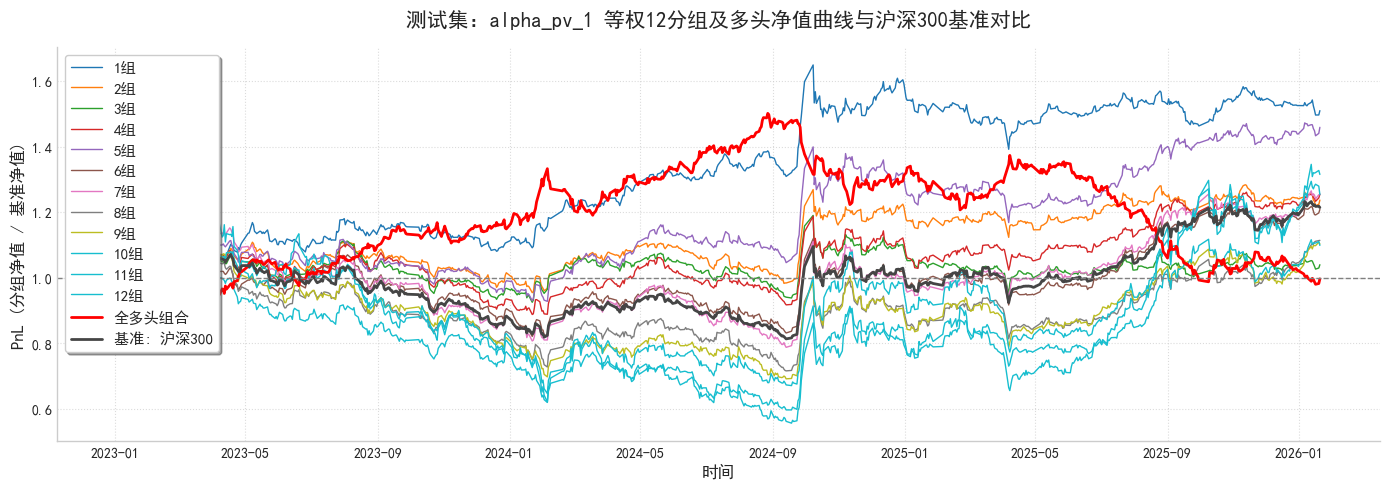

In [17]:
# 针对 alpha_pv_1 
f = 'alpha_pv_1'
factor_pivot = test_weekly.pivot(index='time', columns='code', values=f)

plt.figure(figsize=(14, 5))
ax = plt.gca()
cmap = plt.get_cmap('tab10')

group_returns = {}

for g_num in range(1, 13):
    def get_group_weights(row, g=g_num):
        s = row.dropna()
        if len(s) < 12:
            return pd.Series(0, index=row.index)
        r = s.rank(ascending=False, method='first')
        try:
            groups = pd.qcut(r, q=12, labels=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])
            w = pd.Series(0.0, index=row.index)
            cond = (groups == g)
            if cond.sum() > 0:
                w[s.index[cond]] = 1.0 / cond.sum()
            return w
        except Exception:
            return pd.Series(0, index=row.index)
            
    weekly_w = factor_pivot.apply(get_group_weights, axis=1)
    daily_w = weekly_w.reindex(daily_ret.index).ffill().shift(1).fillna(0)
    strat_daily_ret = (daily_w * daily_ret).sum(axis=1)
    
    group_returns[g_num] = strat_daily_ret
    
    net_value_new = (1 + strat_daily_ret).cumprod()
    plt.plot(net_value_new.index, net_value_new, label=f'{g_num}组', color=cmap(g_num-1), linewidth=1)

long_short_net_value = save_net_value
plt.plot(long_short_net_value.index, long_short_net_value, label='全多头组合', color='red', linewidth=2, linestyle='-')

if 'hs300' in locals():
    hs300_test = hs300.reindex(daily_ret.index).fillna(0)
    bench_daily_ret = hs300_test['ret']
    bench_net_value = (1 + bench_daily_ret).cumprod()
    plt.plot(bench_net_value.index, bench_net_value, label='基准: 沪深300', color='#454545', linewidth=2, linestyle='-')

plt.axhline(1, linestyle='--', color='gray', linewidth=1)
plt.title(f'测试集：{f} 等权12分组及多头净值曲线与沪深300基准对比', fontsize=15, pad=15)
plt.xlabel('时间', fontsize=12)
plt.ylabel('PnL (分组净值 / 基准净值)', fontsize=12)

plt.grid(True, linestyle=':', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.legend(loc='upper left', fontsize=11, frameon=True, fancybox=True, shadow=True)
plt.tight_layout()
plt.savefig(f'./Pictures/Hw4_pv1.png', dpi=300)
plt.show()

In [18]:
import pandas as pd
import numpy as np

data = pd.read_csv("./Data/HS300_data/data.csv")
fund_cols = ['market_cap', 'basic_eps', 'pe_ratio']
price_cols = ['close', 'open', 'turnover_ratio']
use_cols = ['time', 'code'] + price_cols + fund_cols
df_export = data[use_cols].copy()

df_export = df_export.dropna(subset=['time', 'code'])
df_export['time'] = pd.to_datetime(df_export['time'], errors='coerce')
num_cols = price_cols + fund_cols
df_export[num_cols] = df_export[num_cols].apply(pd.to_numeric, errors='coerce')
df_export = df_export.sort_values(['code', 'time']).reset_index(drop=True)
df_export['ret'] = df_export.groupby('code')['close'].pct_change()
df_export[fund_cols] = df_export.groupby('code')[fund_cols].ffill()

# 计算因子: alpha
df_export['abs_overnight_ret'] = (df_export['open'] / df_export.groupby('code')['close'].shift(1) - 1).abs()
df_export['prev_turnover'] = df_export.groupby('code')['turnover_ratio'].shift(1)
df_export['alpha'] = -df_export.groupby('code').apply(
    lambda x: x['abs_overnight_ret'].rolling(20).corr(x['prev_turnover'])
).reset_index(level=0, drop=True)

# 计算因子: alpha_pv_1, 2, 3
df_export['alpha_pv_1'] = -df_export.groupby('code')['turnover_ratio'].transform(lambda x: x.rolling(20).mean())
df_export['alpha_pv_2'] = -df_export.groupby('code')['turnover_ratio'].transform(lambda x: x.rolling(5, min_periods=5).std())
df_export['alpha_pv_3'] = -df_export.groupby('code')['ret'].transform(lambda x: x.rolling(5, min_periods=5).mean())

# 计算因子: alpha_fund_1, 2, 3
df_export['alpha_fund_1'] = -df_export.groupby('code')['market_cap'].transform(lambda x: x.pct_change(20))
ep_pe = 1 / df_export['pe_ratio'].replace(0, np.nan)
df_export['alpha_fund_2'] = ep_pe.groupby(df_export['time']).rank(pct=True)
ep = df_export['basic_eps'] / df_export['close'].replace(0, np.nan)
df_export['alpha_fund_3'] = ep.groupby(df_export['time']).rank(pct=True)

seven_factors = ['alpha', 'alpha_pv_1', 'alpha_pv_2', 'alpha_pv_3', 'alpha_fund_1', 'alpha_fund_2', 'alpha_fund_3']

# 截面 MAD 去极值
def mad_filter(series):
    md = series.median()
    mad = (series - md).abs().median()
    mad_e = 1.483 * mad
    upper = md + 3 * mad_e
    lower = md - 3 * mad_e
    return series.clip(lower=lower, upper=upper)

for f in seven_factors:
    df_export[f] = df_export.groupby('time', group_keys=False)[f].apply(mad_filter)

# 仅保留测试集
df_export = df_export.dropna(subset=['time']).sort_values(['code', 'time'])
test_full = df_export[df_export['time'] >= '2023-01-01'].copy()

# 重采样为周频 (调仓频率)
cols = ['time', 'code', 'open', 'close'] + seven_factors
weekly_df = test_full[cols].copy()
agg_dict = {'open': 'first', 'close': 'last', **{f: 'last' for f in seven_factors}}
test_w = (
    weekly_df.groupby(['code', pd.Grouper(key='time', freq='W-Fri')], observed=True)
    .agg(agg_dict)
    .dropna(subset=['close'])
    .reset_index()
)
test_w['close'] = pd.to_numeric(test_w['close'], errors='coerce')
test_w['next_ret'] = test_w.groupby('code', observed=True)['close'].shift(-1) / test_w['close'] - 1
test_w = test_w.dropna(subset=['next_ret']).reset_index(drop=True)

prefix = "2300010880_王瑾琛_"

# 1. 因子取值计算结果
factor_values = test_w[['time', 'code'] + seven_factors].copy()
factor_values.sort_values(['time', 'code'], inplace=True)
factor_values.to_csv(f"./{prefix}因子取值计算结果.csv", index=False)

# 2. 因子策略权重结果 4. 策略日收益率结果
def get_position_weights(row):
    s = row.dropna()
    if len(s) < 12: return pd.Series(0.0, index=row.index)
    
    s_min = s.min()
    s_max = s.max()
    if s_max == s_min:
        return pd.Series(1.0 / len(s), index=s.index).reindex(row.index, fill_value=0.0)
        
    s_mapped = (s - s_min) / (s_max - s_min)
    w = s_mapped / s_mapped.sum()
    return w.reindex(row.index, fill_value=0.0)

daily_ret = test_full.pivot(index='time', columns='code', values='ret').fillna(0)
daily_strat_rets = {}
weight_records = []

for f in seven_factors:
    factor_pivot = test_w.pivot(index='time', columns='code', values=f)
    weekly_w = factor_pivot.apply(get_position_weights, axis=1)
    
    w_melt = weekly_w.reset_index().melt(id_vars='time', var_name='code', value_name=f)
    weight_records.append(w_melt.set_index(['time', 'code']))
    daily_w = weekly_w.reindex(daily_ret.index).ffill().shift(1).fillna(0)
    daily_strat_rets[f] = (daily_w * daily_ret).sum(axis=1)

# 合并所有因子的权重表
all_weights = pd.concat(weight_records, axis=1).reset_index()
all_weights = all_weights.dropna(subset=seven_factors, how='all')
all_weights.sort_values(['time', 'code'], inplace=True)
all_weights.to_csv(f"./{prefix}因子策略权重结果.csv", index=False)

# 日收益率
daily_rets_df = pd.DataFrame(daily_strat_rets).reset_index()
daily_rets_df.rename(columns={'index': 'time'}, inplace=True, errors='ignore')
daily_rets_df.to_csv(f"./{prefix}策略日收益率结果.csv", index=False)

# 3. 因子IC结果
ic_dict = {}
for f in seven_factors:
    def calc_ic_one_date(x):
        tmp = x[[f, 'next_ret']].dropna()
        if len(tmp) < 20: return np.nan
        return tmp[f].corr(tmp['next_ret'], method='spearman')
    ic_dict[f] = test_w.groupby('time').apply(calc_ic_one_date)
ic_df = pd.DataFrame(ic_dict).reset_index()
ic_df.to_csv(f"./{prefix}因子IC结果.csv", index=False)

print("成功导出")

成功导出
